In [1]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pickle
import joblib

In [2]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/population excel.xlsx')
df

,Year,Yearly % \nChange,Yearly\nChange,Migrants (net),Median Age,Fertility Rate,Density (P/Km²),Urban\nPop %,Urban Population,Country's Share of\nWorld Pop,World Population,India\nGlobal Rank,Population
0,2050,0.23,3711367,NaN,38.1,2.24,551,53.5,876613025,16.84,9735033990,1,1639176033
1,2045,0.35,5585537,-414772.0,36.6,2.24,545,50.1,811749463,17.09,9481803274,1,1620619200
2,2040,0.50,7793541,-415736.0,35.0,2.24,536,46.7,744380367,17.31,9198847240,1,1592691513
3,2035,0.66,10016298,-415732.0,33.3,2.24,523,43.5,675456367,17.48,8887524213,1,1553723810
4,2030,0.80,11726140,-440124.0,31.7,2.24,506,40.4,607341981,17.59,8548487400,1,1503642322
5,2025,0.92,13001447,-464081.0,30.0,2.24,486,37.6,542742539,17.66,8184437460,2,1445011620
6,2020,1.04,13970396,-532687.0,28.4,2.24,464,35.0,483098640,17.70,7794798739,2,1380004385
7,2019,1.02,13775474,-532687.0,27.1,2.36,460,34.5,471828295,17.71,7713468100,2,1366417754
8,2018,1.04,13965495,-532687.0,27.1,2.36,455,34.1,460779764,17.73,7631091040,2,1352642280
9,2017,1.07,14159536,-532687.0,27.1,2.36,450,33.6,449963381,17.74,7547858925,2,1338676785


In [3]:
df[ 'Migrants (net)' ].fillna( df[ 'Migrants (net)']. median() , inplace = True )
df

/tmp/ipykernel_2876/4284016047.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[ 'Migrants (net)' ].fillna( df[ 'Migrants (net)']. median() , inplace = True )


,Year,Yearly % \nChange,Yearly\nChange,Migrants (net),Median Age,Fertility Rate,Density (P/Km²),Urban\nPop %,Urban Population,Country's Share of\nWorld Pop,World Population,India\nGlobal Rank,Population
0,2050,0.23,3711367,-414772.0,38.1,2.24,551,53.5,876613025,16.84,9735033990,1,1639176033
1,2045,0.35,5585537,-414772.0,36.6,2.24,545,50.1,811749463,17.09,9481803274,1,1620619200
2,2040,0.50,7793541,-415736.0,35.0,2.24,536,46.7,744380367,17.31,9198847240,1,1592691513
3,2035,0.66,10016298,-415732.0,33.3,2.24,523,43.5,675456367,17.48,8887524213,1,1553723810
4,2030,0.80,11726140,-440124.0,31.7,2.24,506,40.4,607341981,17.59,8548487400,1,1503642322
5,2025,0.92,13001447,-464081.0,30.0,2.24,486,37.6,542742539,17.66,8184437460,2,1445011620
6,2020,1.04,13970396,-532687.0,28.4,2.24,464,35.0,483098640,17.70,7794798739,2,1380004385
7,2019,1.02,13775474,-532687.0,27.1,2.36,460,34.5,471828295,17.71,7713468100,2,1366417754
8,2018,1.04,13965495,-532687.0,27.1,2.36,455,34.1,460779764,17.73,7631091040,2,1352642280
9,2017,1.07,14159536,-532687.0,27.1,2.36,450,33.6,449963381,17.74,7547858925,2,1338676785


In [4]:
numerical_cols_to_clean = ['Population', 'Urban Population', 'World Population']
for col in numerical_cols_to_clean:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df.dropna(subset=numerical_cols_to_clean, inplace=True)

In [5]:
features = ['Year', 'Yearly % \nChange', 'Yearly\nChange', 'Migrants (net)',
            'Median Age', 'Fertility Rate', 'Density (P/Km²)',
            'Urban\nPop %', 'Urban Population', 'World Population']

X = df[features]
y = df['Population']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

Training samples : 19
Testing  samples : 5


In [7]:
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [8]:
sample = [[2045, 0.35, 5585537, -414772.0, 36.6, 2.24, 545, 50.1, 811749463, 9481803274]]
predicted = dt.predict(sample)
print(f"\nPredicted Population for 2045: {predicted[0]:,.0f}")


Predicted Population for 2045: 1,589,011,508


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [9]:
y_pred = dt.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nR² Score  : {r2:.4f}  (1.0 is perfect)")
print(f"MAE Score : {mae:,.0f}  (how far off on average)")



R² Score  : 0.9593  (1.0 is perfect)
MAE Score : 58,621,138  (how far off on average)


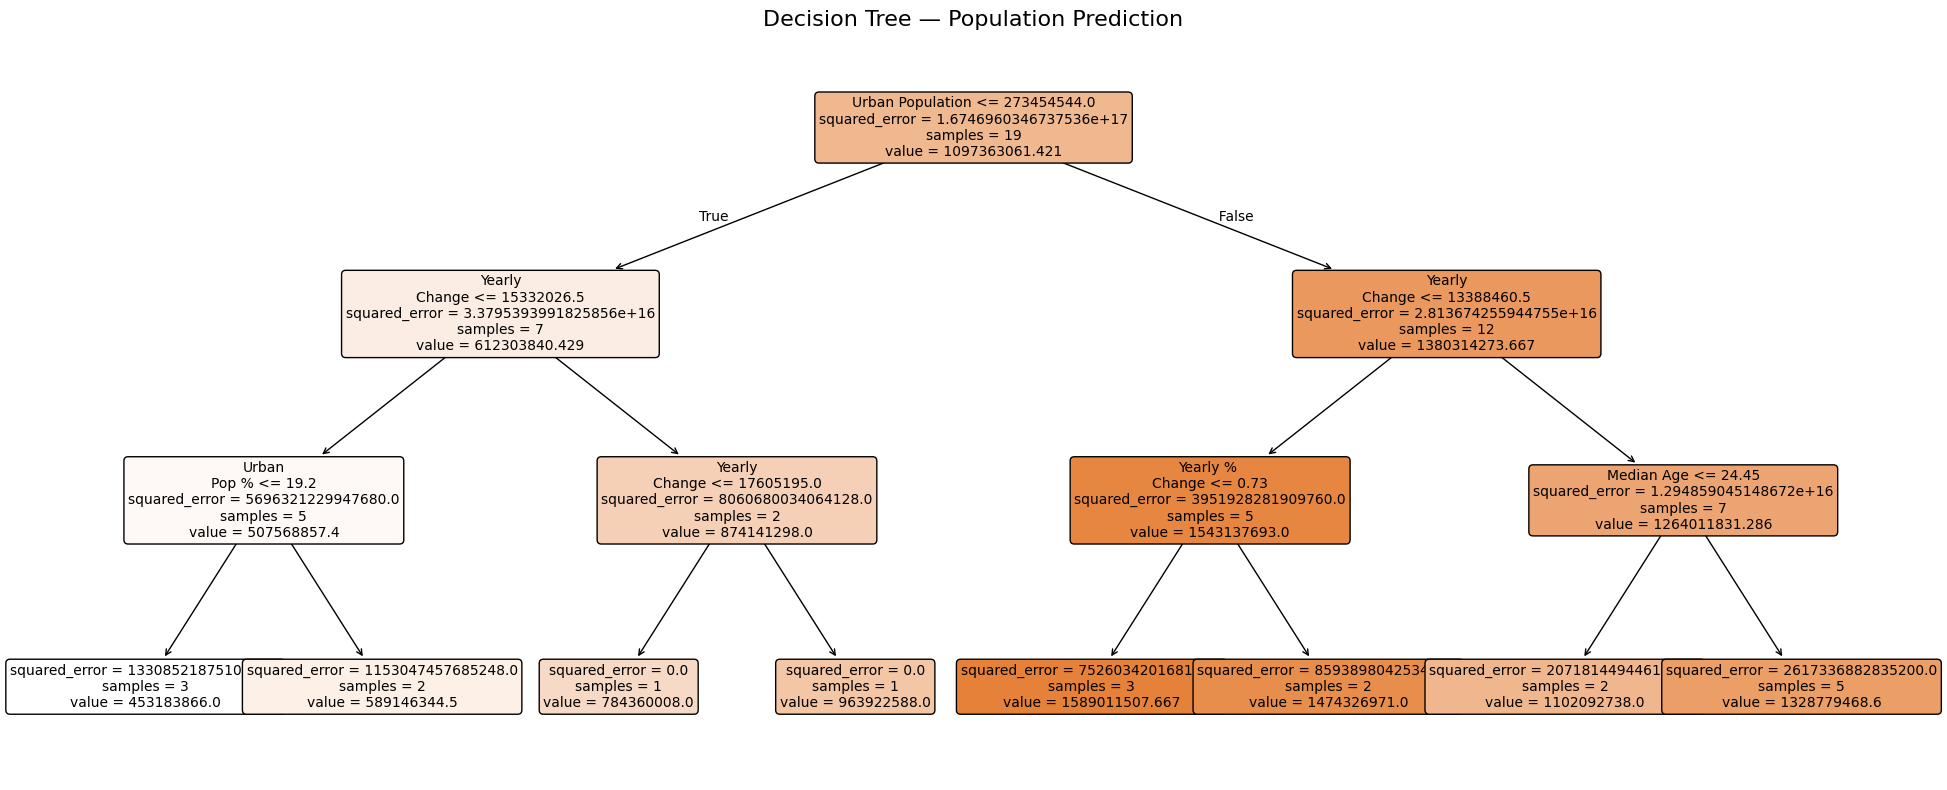

In [10]:
plt.figure(figsize=(20, 8))
tree.plot_tree(dt,
               feature_names=features,
               filled=True,        # color-code the nodes
               rounded=True,       # rounded boxes
               fontsize=10)
plt.title("Decision Tree — Population Prediction", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
importance_df = pd.DataFrame({
    'Feature'   : features,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))


Feature Importances:
          Feature  Importance
 Urban Population    0.826686
   Yearly\nChange    0.138006
       Median Age    0.023272
     Urban\nPop %    0.007032
Yearly % \nChange    0.005003
             Year    0.000000
   Fertility Rate    0.000000
   Migrants (net)    0.000000
  Density (P/Km²)    0.000000
 World Population    0.000000


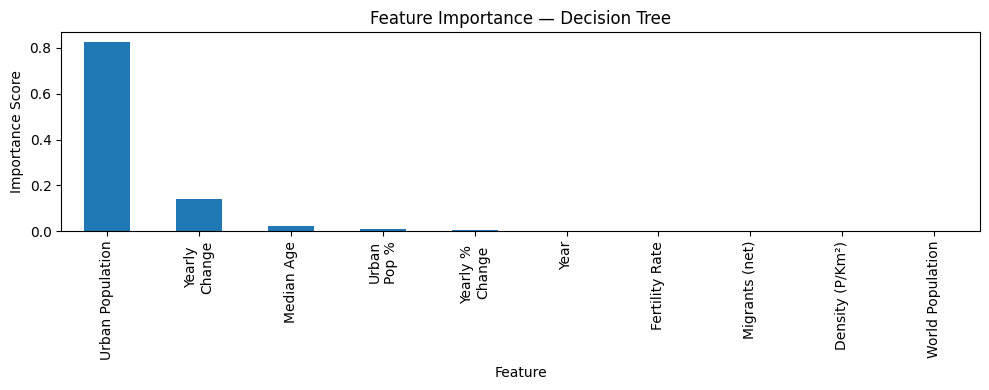

In [12]:
importance_df.plot(kind='bar', x='Feature', y='Importance',
                   legend=False, figsize=(10, 4),
                   title='Feature Importance — Decision Tree')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [13]:
# Too deep = memorizes training data, fails on new data (BAD)
dt_overfit = DecisionTreeRegressor(max_depth=None)  # unlimited depth

# Just right = learns patterns, works on new data (GOOD)
dt_good    = DecisionTreeRegressor(max_depth=3)

# You can experiment:
for depth in [2, 3, 5, 10, None]:
    dt_test = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_test.fit(X_train, y_train)
    score = dt_test.score(X_test, y_test)
    print(f"max_depth={str(depth):<5} → R² = {score:.4f}")

max_depth=2     → R² = 0.9042
max_depth=3     → R² = 0.9593
max_depth=5     → R² = 0.9739
max_depth=10    → R² = 0.9738
max_depth=None  → R² = 0.9738


In [14]:
# ── 9. SAVE & LOAD (same as before) ───────────────────────────────────────────
# Pickle
with open('/content/drive/MyDrive/population_dt.pickle', 'wb') as f:
    pickle.dump(dt, f)

# Load back
with open('/content/drive/MyDrive/population_dt.pickle', 'rb') as f:
    dt2 = pickle.load(f)

print(f"\nLoaded model prediction: {dt2.predict(sample)[0]:,.0f}")

# Joblib (better for larger models)
joblib.dump(dt, '/content/drive/MyDrive/population_dt.joblib')
dt3 = joblib.load('/content/drive/MyDrive/population_dt.joblib')
print(f"Joblib model prediction: {dt3.predict(sample)[0]:,.0f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(



Loaded model prediction: 1,589,011,508
Joblib model prediction: 1,589,011,508


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
